#### IMPORTS

In [1]:
import torchvision
import numpy as np

from dataloader import MyCustomDataset
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
default_dir = os.getcwd()
def default_directory():
    os.chdir(f"{default_dir}")
    print(f"you are back to the default directory: {default_dir}")


In [3]:
default_directory()
os.getcwd()

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN


'/home/karansingh/Documents/summer term/ECG_ML/MAIN'

In [4]:
os.chdir("data_prep")
os.getcwd()

'/home/karansingh/Documents/summer term/ECG_ML/MAIN/data_prep'

In [5]:
# get list of all files in the directory
files = os.listdir()
print(files)

['README.md', 'data_prep.ipynb', 'EXPERIMENT_resnet', 'README copy', 'data_prep_for_only_one_disease.ipynb', 'unq_disease_SB.npy', 'disease_SB.npy', 'unq_disease_ST.npy', 'unq_disease_SR.npy', 'disease_ST.npy', 'disease_SR.npy', 'EXPERIMENT_2', 'EXPERIMENT_resnet_1d']


#### LOAD DATA

In [6]:
data_ST_list = np.load("unq_disease_ST.npy")
data_SB_list = np.load("unq_disease_SB.npy")
data_SR_list = np.load("unq_disease_SR.npy")
#print shape of all loaded files
print("shape of ST data: ", data_ST_list.shape)
print("shape of SB data: ", data_SB_list.shape)
print("shape of SR data: ", data_SR_list.shape)



shape of ST data:  (3000, 5000, 12)
shape of SB data:  (5000, 5000, 12)
shape of SR data:  (5000, 5000, 12)


### sanity check

In [7]:
# check the curupted data
def check_data(data):
    corrupted_indices = []
    for i in range(data.shape[0]):
        if np.isnan(data[i]).any() or np.isinf(data[i]).any():
            corrupted_indices.append(i)
    return corrupted_indices
corrupted_ST = check_data(data_ST_list)
corrupted_SB = check_data(data_SB_list)
corrupted_SR = check_data(data_SR_list)
print("corrupted ST indices: ", corrupted_ST)
print("corrupted SB indices: ", corrupted_SB)
print("corrupted SR indices: ", corrupted_SR)


corrupted ST indices:  [199, 306, 449, 633, 920, 2132, 2141, 2186, 2256]
corrupted SB indices:  [1418, 1852, 1898, 2756, 2881, 3007, 3101, 4091, 4192, 4293, 4376, 4594, 4601, 4720]
corrupted SR indices:  [149, 192, 213, 340, 385, 441, 2341, 2451, 2482, 2534, 4903, 4944]


In [8]:
# now che ck nana and inf difrently
def check_nan_inf(data):
    nan_indices = []
    inf_indices = []
    for i in range(data.shape[0]):
        if np.isnan(data[i]).any():
            nan_indices.append(i)
        if np.isinf(data[i]).any():
            inf_indices.append(i)
    return nan_indices, inf_indices
nan_ST, inf_ST = check_nan_inf(data_ST_list)
nan_SB, inf_SB = check_nan_inf(data_SB_list)
nan_SR, inf_SR = check_nan_inf(data_SR_list)
print("NaN ST indices: ", nan_ST)
print("Inf ST indices: ", inf_ST)
print("NaN SB indices: ", nan_SB)
print("Inf SB indices: ", inf_SB)
print("NaN SR indices: ", nan_SR)
print("Inf SR indices: ", inf_SR)


NaN ST indices:  [199, 306, 449, 633, 920, 2132, 2141, 2186, 2256]
Inf ST indices:  []
NaN SB indices:  [1418, 1852, 1898, 2756, 2881, 3007, 3101, 4091, 4192, 4293, 4376, 4594, 4601, 4720]
Inf SB indices:  []
NaN SR indices:  [149, 192, 213, 340, 385, 441, 2341, 2451, 2482, 2534, 4903, 4944]
Inf SR indices:  []


In [9]:
# Loop over all ST indices with NaNs and summarize locations
nan_summary = {}

for idx in nan_ST:
    sample = data_ST_list[idx]  # shape: (5000, 12)

    # All NaN locations for this sample
    locs = np.argwhere(np.isnan(sample))  # rows, cols
    cols_with_nan = np.unique(locs[:, 1]) if locs.size else np.array([], dtype=int)



    nan_summary[idx] = {
        "count": int(locs.shape[0]),
        "cols": cols_with_nan.tolist()
,
    }

    print(
        f"ST sample {idx}: NaNs={nan_summary[idx]['count']}, "
        f"cols={nan_summary[idx]['cols']}, "
    )

# Optional: access detailed rows for a given sample index, e.g., nan_summary[nan_ST[0]]["rows_in_col"]

ST sample 199: NaNs=3, cols=[11], 
ST sample 306: NaNs=3, cols=[8], 
ST sample 449: NaNs=64, cols=[7], 
ST sample 633: NaNs=21, cols=[11], 
ST sample 920: NaNs=35, cols=[11], 
ST sample 2132: NaNs=68, cols=[8], 
ST sample 2141: NaNs=3, cols=[9], 
ST sample 2186: NaNs=213, cols=[9, 10, 11], 
ST sample 2256: NaNs=62, cols=[11], 


In [10]:
import numpy as np

# Get the array
data = data_ST_list[nan_ST[-2]]
print(f"Array shape: {data.shape}")

# Find exact NaN locations
nan_locations = np.argwhere(np.isnan(data))

print(f"\nTotal NaN values found: {len(nan_locations)}")
print("\nNaN locations (row, column):")
for row, col in nan_locations:
    print(f"  NaN at row {row}, column {col}")

Array shape: (5000, 12)

Total NaN values found: 213

NaN locations (row, column):
  NaN at row 0, column 9
  NaN at row 1, column 9
  NaN at row 2, column 9
  NaN at row 3, column 9
  NaN at row 4, column 9
  NaN at row 5, column 9
  NaN at row 429, column 10
  NaN at row 437, column 10
  NaN at row 449, column 10
  NaN at row 450, column 10
  NaN at row 451, column 10
  NaN at row 452, column 10
  NaN at row 453, column 10
  NaN at row 454, column 10
  NaN at row 455, column 10
  NaN at row 456, column 10
  NaN at row 457, column 10
  NaN at row 458, column 10
  NaN at row 459, column 10
  NaN at row 460, column 10
  NaN at row 461, column 10
  NaN at row 462, column 10
  NaN at row 463, column 10
  NaN at row 464, column 10
  NaN at row 465, column 10
  NaN at row 466, column 10
  NaN at row 467, column 10
  NaN at row 468, column 10
  NaN at row 469, column 10
  NaN at row 470, column 10
  NaN at row 471, column 10
  NaN at row 472, column 10
  NaN at row 473, column 10
  NaN at ro

In [12]:
# remove corrupted data from all three datasets
def remove_corrupted_data(data_list, corrupted_indices):
    return np.delete(data_list, corrupted_indices, axis=0)
    return cleaned_data

data_ST_list = remove_corrupted_data(data_ST_list, nan_ST + inf_ST)
data_SB_list = remove_corrupted_data(data_SB_list, nan_SB + inf_SB)
data_SR_list = remove_corrupted_data(data_SR_list, nan_SR + inf_SR)

### creating batches


In [13]:

# lead 1
# Use ALL 12 leads
images = data_ST_list          # shape: (N_ST, T, 12)
labels = np.zeros(images.shape[0])

# SB
images = np.concatenate((images, data_SB_list), axis=0)
labels = np.concatenate((labels, np.ones(data_SB_list.shape[0])))

# SR
images = np.concatenate((images, data_SR_list), axis=0)
labels = np.concatenate((labels, 2*np.ones(data_SR_list.shape[0])))

print("we have", images.shape[0], "samples and", labels.shape[0], "labels")
print("raw shape:", images.shape)

                    

we have 12965 samples and 12965 labels
raw shape: (12965, 5000, 12)


In [14]:
len(images),len(labels)

(12965, 12965)

In [15]:
from sklearn.model_selection import train_test_split

X = images        # (12965, 5000, 12)
y = labels      # (12965,)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#split is of 70% train, 15% val, 15% test


In [16]:
# compute stats on TRAIN set only
mean = X_train.mean(axis=(0, 1))   # (12,)
std  = X_train.std(axis=(0, 1))    # (12,)

std[std < 1e-6] = 1e-6  # safety


In [17]:
# apply normalization
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std


#### transposing data

In [18]:
# (batch, time, channels) → (batch, channels, time)
X_train = X_train.transpose(0, 2, 1)
X_val   = X_val.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)


In [19]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_ds, batch_size=32, shuffle=False)

#### CREATE BATCHES

#### TRAINING PARAMETERS

In [22]:
default_directory()

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN


In [23]:
from vanilla_transformer_ecg import VanillaTransformerECG
num_leads = 12
signal_length = 5000
num_classes = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = VanillaTransformerECG(
    num_leads=num_leads,
    signal_length=signal_length,
    num_classes=num_classes,
    d_model=128,
    nhead=8,
    num_layers=4,
    dim_feedforward=512,
    dropout=0.1,
    patch_size=50
).to(device)


Using device: cuda


#### resnettorch vision


In [24]:
default_directory()
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
import importlib, plots
importlib.reload(plots)
from plots import evaluate_all
from seed_utils import set_seed, SEEDS


# ── 1. Setup multi-seed tracking ──
all_metrics = []
all_histories = []

log_dir = "EXPERIMENT_2d_transformer_typ1_VanillaTransformerECG_randomseed"
os.makedirs(log_dir, exist_ok=True)

# Try getting notebook name
try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "main_2d_transformer_VanillaTransformerECG_typ1"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

# ── 2. Loop through seeds ──
for seed in SEEDS:
    namkaran = f"2d_transformer_VanillaTransformerECGlr1e-4_seed{seed}"
    log_path = os.path.join(log_dir, f"{notebook_name}_{namkaran}.txt")

    # Use our seed utility!
    set_seed(seed)

    with open(log_path, "a") as f:
        log_print("\n" + "="*60, f)
        log_print(f"Training Run Started for Seed {seed}: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
        log_print("="*60, f)

        # Initialize model inside loop to reset weights!
        model = VanillaTransformerECG(
            num_leads=12,
            signal_length=5000,
            num_classes=3,
            d_model=128,
            nhead=8,
            num_layers=4,
            dim_feedforward=512,
            dropout=0.1,
            patch_size=50
        ).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )

        def correct(pred, true):
            return (pred == true).sum().item()

        train_losses_list, val_losses_list = [], []
        accuracy_train_list, accuracy_val_list = [], []
        best_acc, wait, best_model = 0, 0, None
        num_epochs, patience = 25, 7
        total_start_time = time.time()

        for epoch in range(num_epochs):
            epoch_start_time = time.time()

            # --- Train ---
            model.train()
            run_loss = 0
            c_train = t_train = 0
            train_start_time = time.time()
            for x, y in train_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                run_loss += loss.item()
                c_train += correct(out.argmax(1), y)
                t_train += y.size(0)

            train_time = time.time() - train_start_time
            train_losses_list.append(run_loss / len(train_dataloader))
            accuracy_train_list.append(100 * c_train / t_train)

            # --- Validation ---
            model.eval()
            run_loss = 0
            c_val = t_val = 0
            val_start_time = time.time()
            with torch.no_grad():
                for x, y in val_dataloader:
                    x, y = x.to(device), y.to(device)
                    out = model(x)
                    loss = criterion(out, y)
                    run_loss += loss.item()
                    c_val += correct(out.argmax(1), y)
                    t_val += y.size(0)

            val_time = time.time() - val_start_time
            val_losses_list.append(run_loss / len(val_dataloader))
            accuracy_val_list.append(100 * c_val / t_val)

            # --- LR scheduler ---
            old_lr = optimizer.param_groups[0]["lr"]
            scheduler.step(val_losses_list[-1])
            lr_now = optimizer.param_groups[0]["lr"]

            if lr_now != old_lr:
                log_print(f"  >> Learning rate reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

            # --- Early stopping ---
            if accuracy_val_list[-1] > best_acc:
                best_acc, wait = accuracy_val_list[-1], 0
                best_model = copy.deepcopy(model.state_dict())
            else:
                wait += 1
                if wait >= patience:
                    log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                    break

            epoch_time = time.time() - epoch_start_time
            log_print(
                f"Epoch [{epoch + 1}/{num_epochs}] | "
                f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
                f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
                f"LR: {lr_now:.6f} | "
                f"Time: {epoch_time:.2f}s", f
            )

        total_training_time = time.time() - total_start_time

        # Restore best weights and save
        model.load_state_dict(best_model)
        torch.save(best_model, os.path.join(log_dir, f"{notebook_name}_{namkaran}.pth"))
        log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

        log_print("="*60, f)
        log_print(f"Total Training Time: {total_training_time:.2f}s", f)

        # ── 3. Evaluate the seed silently and store results ──
        log_print(f"Evaluating best model on test set for seed {seed}...", f)
        results = evaluate_all(
            model, test_dataloader, device,
            plot_confusion_matrix=False,
            plot_pr_micro=False,
            plot_pr_per_class=False,
            plot_roc=False,
            print_report=False
        )
        all_metrics.append(results)

        history = {
            "train_acc": accuracy_train_list,
            "val_acc": accuracy_val_list,
            "train_loss": train_losses_list,
            "val_loss": val_losses_list
        }
        all_histories.append(history)

print("\n ALL 5 SEEDS COMPLETED!")

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN

Training Run Started for Seed 40: 2026-07-02 11:52:44
Epoch [1/25] | Train Loss: 0.6426, Val Loss: 0.3884, Train Acc: 69.18%, Val Acc: 83.80%, LR: 0.000100 | Time: 6.90s
Epoch [2/25] | Train Loss: 0.3625, Val Loss: 0.3204, Train Acc: 85.01%, Val Acc: 86.99%, LR: 0.000100 | Time: 6.76s
Epoch [3/25] | Train Loss: 0.3079, Val Loss: 0.3196, Train Acc: 87.32%, Val Acc: 87.04%, LR: 0.000100 | Time: 6.76s
Epoch [4/25] | Train Loss: 0.2733, Val Loss: 0.2741, Train Acc: 88.85%, Val Acc: 88.95%, LR: 0.000100 | Time: 6.74s
Epoch [5/25] | Train Loss: 0.2441, Val Loss: 0.2513, Train Acc: 90.08%, Val Acc: 90.23%, LR: 0.000100 | Time: 6.69s
Epoch [6/25] | Train Loss: 0.2315, Val Loss: 0.2763, Train Acc: 90.35%, Val Acc: 88.12%, LR: 0.000100 | Time: 6.67s
Epoch [7/25] | Train Loss: 0.2330, Val Loss: 0.2405, Train Acc: 90.51%, Val Acc: 90.85%, LR: 0.000100 | Time: 6.67s
Epoch [8/25] | Train Loss: 0.2072, Val Loss


  MULTI-SEED SUMMARY  (5 seeds: 40–44)
Metric                     Mean        Std
------------------------------------------
  accuracy               93.00% ± 0.75%     
  f1_macro               0.9310 ± 0.0072    
  f1_micro               0.9300 ± 0.0075    
  auc_macro              0.9877 ± 0.0014    
  ap_micro               0.9793 ± 0.0026    
----------------------------------------------------------------------------------------------------
  PER-CLASS CLASSIFICATION REPORT (Mean ± Std)
----------------------------------------------------------------------------------------------------
  Class           Precision            Recall               F1-Score             AUC                  Support
----------------------------------------------------------------------------------------------------
  ST              0.9164 ± 0.0118      0.9635 ± 0.0110      0.9392 ± 0.0054      0.9934 ± 0.0004      449.0
  SB              0.9416 ± 0.0103      0.9492 ± 0.0168      0.9452 ± 0.0063      

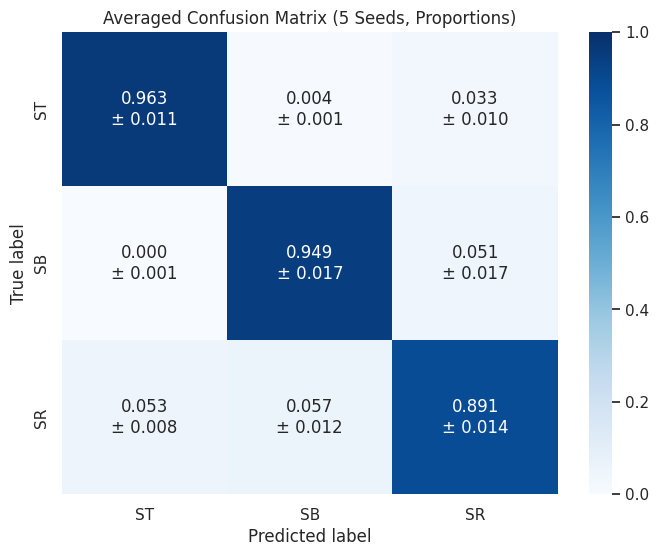

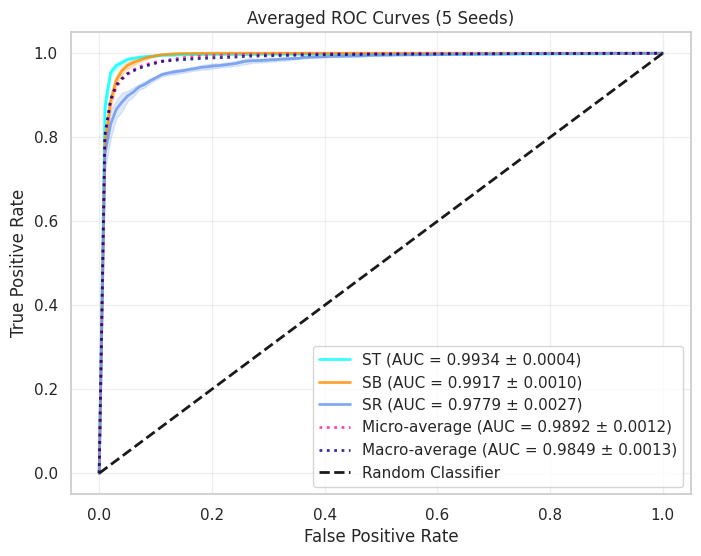

AUC Scores (Mean ± Std):
------------------------------
Class ST: 0.9934 ± 0.0004
Class SB: 0.9917 ± 0.0010
Class SR: 0.9779 ± 0.0027
Micro-average: 0.9892 ± 0.0012
Macro-average: 0.9849 ± 0.0013
------------------------------



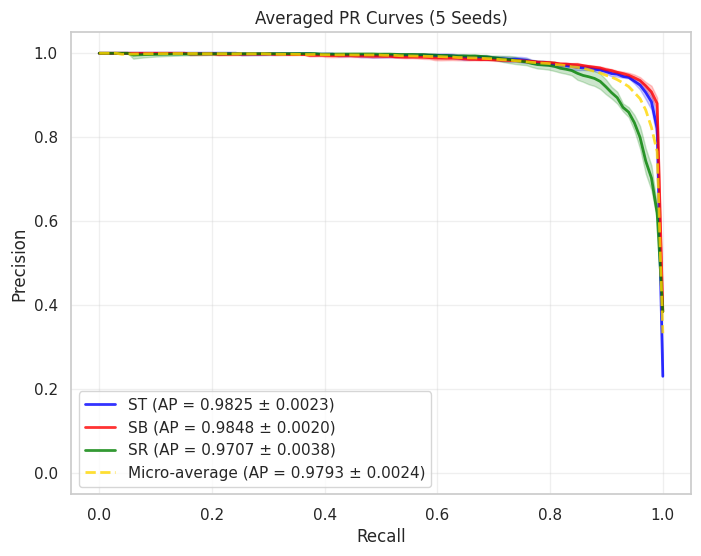

Saved: EXPERIMENT_2d_transformer_typ1_VanillaTransformerECG_randomseed/2d_transformer_VanillaTransformerECGlr1e-4_seed44_val_acc_multiseed.png


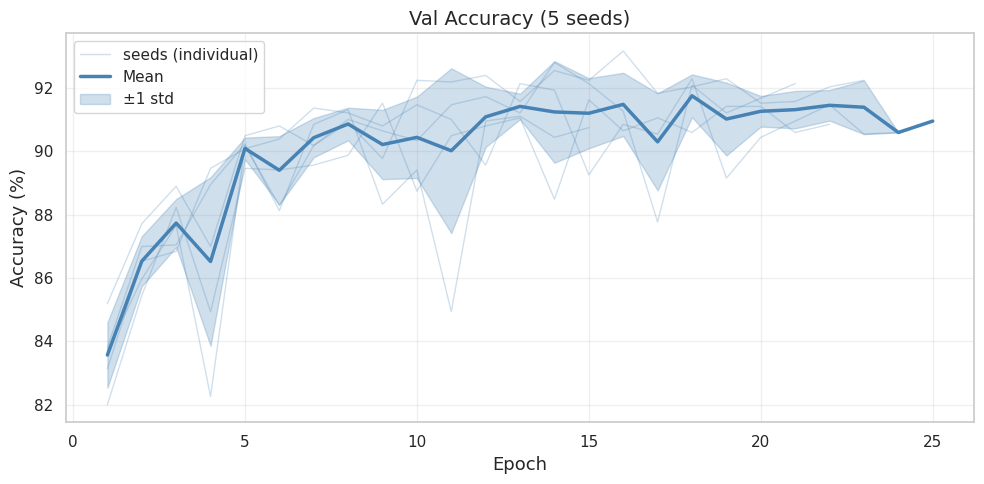

Saved: EXPERIMENT_2d_transformer_typ1_VanillaTransformerECG_randomseed/2d_transformer_VanillaTransformerECGlr1e-4_seed44_val_loss_multiseed.png


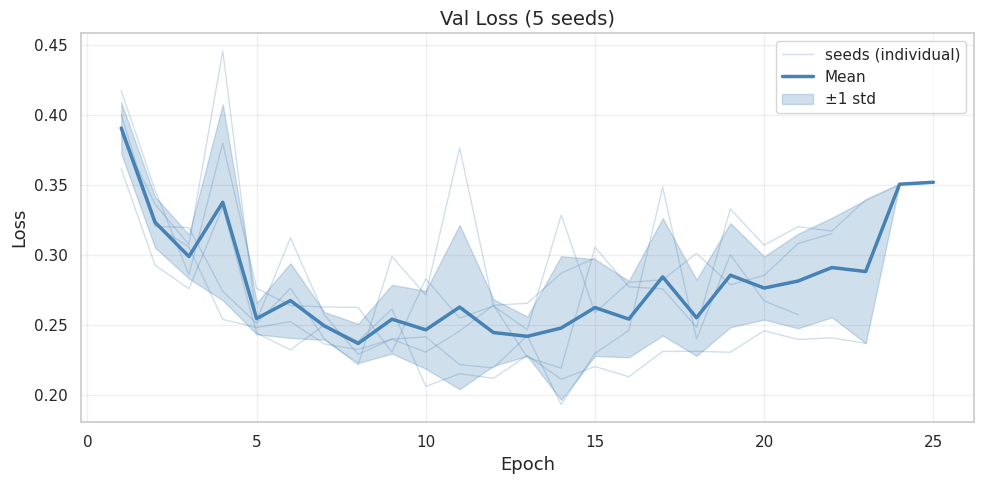

In [25]:
import importlib, plots
importlib.reload(plots)
from plots import plot_learning_curves_multiseed, summarize_seed_results, evaluate_multiseed_plots

# 1. Prints the classification report table and saves the CSV
summarize_seed_results(
    all_metrics,
    save_csv=os.path.join(log_dir, f"{namkaran}_multiseed_summary.csv"),
)

# 2. Plots and saves Averaged CM (Proportions), ROC (+ text AUCs), and PR curves
evaluate_multiseed_plots(
    all_metrics, 
    class_names=["ST", "SB", "SR"],
    save_dir=log_dir,
    namkaran=namkaran
)

# 3. Plots and saves Learning Curves (Accuracy & Loss)
plot_learning_curves_multiseed(
    all_histories, metric="val_acc",
    title=f"Val Accuracy (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_acc_multiseed.png"),
)
plot_learning_curves_multiseed(
    all_histories, metric="val_loss",
    title=f"Val Loss (5 seeds)",
    save_path=os.path.join(log_dir, f"{namkaran}_val_loss_multiseed.png"),
)
